# 🎬 Face2FaceRHO — 영상 합성 파이프라인

**driving 영상을 프레임 단위로 분리 → 메타데이터 변환 → 얼굴 합성 → 영상 재결합**

> ⚠️ 이 노트북은 `Face2FaceRHO.ipynb`의 환경(레포 클론, 모델 파일 준비)이 완료된 상태를 전제합니다.

---
## 메타데이터 → Face2FaceRHO 포맷 변환 설명

| JSON 필드 | Face2FaceRHO 입력 | 설명 |
|-----------|-------------------|------|
| `tdmm_raw.coeffs[200:206]` | `headpose.txt` | DECA 기준 전역 회전 3값(axis-angle) + 턱 회전 3값, 각 값을 한 줄씩 기록 |
| `tdmm_raw.coeffs[150:200]` + bbox → 프로젝션 | `landmark.txt` | expression coeffs와 bbox로 근사 2D 랜드마크 72점 생성, 정규화된 (x, y) 한 줄씩 |
| `bbox` (x, y, w, h) | 필터링 기준 | 너무 작은 얼굴 제외 — `MIN_FACE_AREA` 변수로 조정 |

> **주의**: JSON의 `tdmm_raw`는 FLAME 3DMM 계수를 양자화한 raw 값입니다.  
> Face2FaceRHO가 기대하는 값과 스케일이 다를 수 있으므로, `COEFF_SCALE` 변수로 보정합니다.

## STEP 0 — 경로 및 파라미터 설정

In [ ]:
!nvidia-smi
import torch, sys
print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"GPU 사용: {torch.cuda.is_available()}")

Tue Mar 24 13:28:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

if not os.path.exists('/content/Face2FaceRHO'):
    !git clone https://github.com/NetEase-GameAI/Face2FaceRHO.git
else:
    print("이미 클론됨 — 스킵")

%cd /content/Face2FaceRHO
!git submodule update --init --recursive
print("✅ 클론 완료")

Cloning into 'Face2FaceRHO'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 119 (delta 8), reused 116 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 6.61 MiB | 12.19 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Face2FaceRHO
✅ 클론 완료


In [ ]:
# 기본 패키지
!pip install -q kornia yacs ninja trimesh
!pip install -q face-alignment==1.3.4
!pip install -q opencv-python-headless imageio imageio-ffmpeg
print("✅ 패키지 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 128.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ 패키지 설치 완료


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

# =============================================
# ↓ 본인의 드라이브 경로로 수정하세요
DRIVE_BASE = '/content/drive/MyDrive/Face2FaceRHO_models'
# =============================================

os.makedirs('./src/checkpoints/voxceleb_face2facerho', exist_ok=True)
os.makedirs('./src/external/data', exist_ok=True)

tasks = [
    (f'{DRIVE_BASE}/voxceleb_face2facerho', './src/checkpoints/', 'dir'),
    (f'{DRIVE_BASE}/generic_model.pkl',     './src/external/data/generic_model.pkl', 'file'),
    (f'{DRIVE_BASE}/deca_model.tar',        './src/external/data/deca_model.tar', 'file'),
]

for src, dst, kind in tasks:
    if os.path.exists(src):
        if kind == 'dir':
            shutil.copytree(src, dst + os.path.basename(src), dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
        print(f"✅ 복사 완료: {os.path.basename(src)}")
    else:
        print(f"❌ 파일 없음: {src}")

✅ 복사 완료: voxceleb_face2facerho
✅ 복사 완료: generic_model.pkl
✅ 복사 완료: deca_model.tar


In [ ]:
# 모델 파일 존재 여부 확인
checks = [
    './src/checkpoints/voxceleb_face2facerho',
    './src/external/data/generic_model.pkl',
    './src/external/data/deca_model.tar',
]
all_ok = True
for p in checks:
    ok = os.path.exists(p)
    print(f"{'✅' if ok else '❌'} {p}")
    if not ok: all_ok = False
print()
print("🚀 모든 파일 준비 완료!" if all_ok else "⛔ 위 ❌ 항목을 먼저 해결하세요.")

✅ ./src/checkpoints/voxceleb_face2facerho
✅ ./src/external/data/generic_model.pkl
✅ ./src/external/data/deca_model.tar

🚀 모든 파일 준비 완료!


In [ ]:
# Drive 폴더 내 파일 목록 확인
import os

# =============================================
# ↓ STEP 2에서 설정한 DRIVE_BASE와 동일한 경로
# =============================================
DRIVE_BASE = '/content/drive/MyDrive/Face2FaceRHO_models'

print("Drive 폴더 내 파일 목록:")
if os.path.exists(DRIVE_BASE):
    for f in sorted(os.listdir(DRIVE_BASE)):
        size = os.path.getsize(os.path.join(DRIVE_BASE, f))
        print(f"  {f}  ({size/1024/1024:.1f} MB)")
else:
    print(f"❌ {DRIVE_BASE} 경로가 없습니다. Drive 마운트(STEP 2)를 먼저 실행하세요.")

Drive 폴더 내 파일 목록:
  deca_model.tar  (414.0 MB)
  face_meta.mp4  (13.1 MB)
  generic_model.pkl  (50.6 MB)
  metadata_1774237242321.json  (3.0 MB)
  voxceleb_face2facerho  (0.0 MB)


In [ ]:
import os, glob, shutil

# =============================================
# ↓ 위 셀에서 확인한 파일명으로 수정하세요
# =============================================
DRIVING_VIDEO_NAME  = 'face_meta.mp4'                    # driving 영상 파일명
METADATA_JSON_NAME  = 'metadata_1774237242321.json'       # 메타데이터 파일명
# =============================================

# Drive → /content 로 복사 (반복 실행 시 스킵)
DRIVING_VIDEO = f'/content/{DRIVING_VIDEO_NAME}'
METADATA_JSON = f'/content/{METADATA_JSON_NAME}'

for name, dst in [(DRIVING_VIDEO_NAME, DRIVING_VIDEO), (METADATA_JSON_NAME, METADATA_JSON)]:
    src_path = f'{DRIVE_BASE}/{name}'
    if not os.path.exists(dst):
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst)
            print(f'✅ 복사 완료: {name}')
        else:
            print(f'❌ Drive에서 파일을 찾을 수 없음: {src_path}')
    else:
        print(f'⏭️  이미 존재 — 스킵: {dst}')

# source 이미지: 레포 클론 후 test_case 경로 사용
SOURCE_IMG_DEFAULT = '/content/Face2FaceRHO/test_case/source/source.jpg'

# tracking_id별 다른 source를 쓰고 싶을 때만 아래를 채우세요
# 비워두면 SOURCE_IMG_DEFAULT 를 전체 ID에 적용
SOURCE_PER_ID = {
    # 예시: 0: '/content/drive/MyDrive/Face2FaceRHO_models/source_A.jpg',
    #       2: '/content/drive/MyDrive/Face2FaceRHO_models/source_B.jpg',
}

# 출력 경로
OUTPUT_DIR   = '/content/output_frames'
OUTPUT_VIDEO = '/content/output.mp4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 최종 확인
for label, path in [('driving', DRIVING_VIDEO), ('metadata', METADATA_JSON), ('source', SOURCE_IMG_DEFAULT)]:
    ok = os.path.exists(path)
    print(f"{'✅' if ok else '❌'} {label}: {path}")

✅ 복사 완료: face_meta.mp4
✅ 복사 완료: metadata_1774237242321.json
✅ driving: /content/face_meta.mp4
✅ metadata: /content/metadata_1774237242321.json
✅ source: /content/Face2FaceRHO/test_case/source/source.jpg


In [ ]:
import os

# ============================================================
#  ↓ 필요에 따라 수정하세요
# ============================================================

# Face2FaceRHO 레포 루트
REPO_ROOT = '/content/Face2FaceRHO'

# Source 이미지 (기준 얼굴)
SRC_IMG        = f'{REPO_ROOT}/test_case/source/source.jpg'
SRC_HEADPOSE   = f'{REPO_ROOT}/test_case/source/original/headpose.txt'
SRC_LANDMARK   = f'{REPO_ROOT}/test_case/source/original/landmark.txt'

# Driving 영상 & 메타데이터
DRIVING_VIDEO  = '/content/face_meta.mp4'
METADATA_JSON  = '/content/metadata_1774237242321.json'

# 출력 디렉토리
OUT_FRAMES_DIR = '/content/pipeline_output/frames'      # 원본 프레임
OUT_META_DIR   = '/content/pipeline_output/meta'        # 변환된 headpose/landmark
OUT_SYNTH_DIR  = '/content/pipeline_output/synthesized' # 합성 결과 프레임
OUT_VIDEO_PATH = '/content/pipeline_output/output.mp4'  # 최종 영상

# -------- 필터링 파라미터 --------
# 얼굴 bbox 면적(px²) 이하는 합성 대상에서 제외
MIN_FACE_AREA  = 4000   # ← 수정 가능 (예: 2000 ~ 10000)

# -------- DECA coeffs 레이아웃 (265차원) --------
# 아래 인덱스는 FLAME/DECA 표준 레이아웃 기준입니다.
# metadata JSON의 tdmm_raw.coeffs 구조:
#   [0:100]   shape params
#   [100:150] texture params
#   [150:200] expression params  (50차원)
#   [200:206] pose params        (6차원 → headpose.txt)
#              [200:203] global rotation (axis-angle, pitch/yaw/roll)
#              [203:206] jaw rotation
#   [206:209] camera params      (scale, tx, ty)
#   [209:236] light params
#   [236:265] detail / extra
POSE_SLICE  = (200, 206)   # headpose.txt에 사용할 계수 슬라이스
EXP_SLICE   = (150, 200)   # landmark 근사에 보조로 사용
CAM_SLICE   = (206, 209)   # 카메라 파라미터 (scale, tx, ty)

# -------- Face2FaceRHO config --------
F2F_CONFIG = f'{REPO_ROOT}/src/config/test_face2facerho.ini'

# -------- 영상 FPS (메타데이터에서 자동 감지, 실패 시 fallback) --------
FALLBACK_FPS = 30

print('✅ 파라미터 설정 완료')
print(f'   MIN_FACE_AREA  = {MIN_FACE_AREA} px²')
print(f'   DRIVING_VIDEO  = {DRIVING_VIDEO}')
print(f'   METADATA_JSON  = {METADATA_JSON}')
print(f'   SRC_IMG        = {SRC_IMG}')

✅ 파라미터 설정 완료
   MIN_FACE_AREA  = 4000 px²
   DRIVING_VIDEO  = /content/face_meta.mp4
   METADATA_JSON  = /content/metadata_1774237242321.json
   SRC_IMG        = /content/Face2FaceRHO/test_case/source/source.jpg


## STEP 1 — 라이브러리 임포트 & 출력 디렉토리 생성

In [ ]:
import cv2
import json
import math
import numpy as np
import shutil
import subprocess
import sys
from pathlib import Path
from tqdm.notebook import tqdm

for d in [OUT_FRAMES_DIR, OUT_META_DIR, OUT_SYNTH_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ 라이브러리 임포트 완료')
print('✅ 출력 디렉토리 생성 완료')

✅ 라이브러리 임포트 완료
✅ 출력 디렉토리 생성 완료


## STEP 2 — Driving 영상 → 프레임 분리

In [ ]:
def extract_frames(video_path: str, out_dir: str) -> tuple[list[str], float]:
    """
    영상을 프레임 단위로 분리하여 PNG로 저장합니다.
    Returns:
        frame_paths : 저장된 프레임 파일 경로 목록 (정렬됨)
        fps         : 영상 FPS
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f'영상 파일을 열 수 없습니다: {video_path}')

    fps        = cap.get(cv2.CAP_PROP_FPS) or FALLBACK_FPS
    total      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w          = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h          = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f'📹 영상 정보: {w}×{h}, {fps:.2f} fps, 총 {total} 프레임')

    frame_paths = []
    idx = 0
    pbar = tqdm(total=total, desc='프레임 분리')
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out_path = os.path.join(out_dir, f'frame_{idx:06d}.png')
        cv2.imwrite(out_path, frame)
        frame_paths.append(out_path)
        idx += 1
        pbar.update(1)

    cap.release()
    pbar.close()
    print(f'✅ {len(frame_paths)}개 프레임 저장 완료 → {out_dir}')
    return sorted(frame_paths), fps


frame_paths, video_fps = extract_frames(DRIVING_VIDEO, OUT_FRAMES_DIR)
print(f'   FPS: {video_fps:.2f}')

📹 영상 정보: 1280×720, 23.01 fps, 총 792 프레임


프레임 분리:   0%|          | 0/792 [00:00<?, ?it/s]

✅ 792개 프레임 저장 완료 → /content/pipeline_output/frames
   FPS: 23.01


## STEP 3 — 메타데이터 파싱 및 프레임 매핑

`pts_us`(마이크로초 타임스탬프)를 기준으로 각 메타데이터 항목을 가장 가까운 영상 프레임에 매핑합니다.

In [ ]:
def load_metadata(json_path: str) -> list[dict]:
    """JSON 파일을 읽어 'frames' 리스트를 반환합니다."""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    frames = data.get('frames', [])
    print(f'📄 메타데이터 로드: 총 {len(frames)}개 항목')
    faces_count = sum(1 for fr in frames if fr.get('faces'))
    print(f'   얼굴 감지된 항목: {faces_count}개 ({faces_count/len(frames)*100:.1f}%)')
    return frames


def map_metadata_to_frames(
    meta_frames: list[dict],
    frame_paths: list[str],
    fps: float
) -> list[dict | None]:
    """
    pts_us 타임스탬프 → 영상 프레임 인덱스로 매핑합니다.
    각 영상 프레임에 대해 가장 가까운 메타데이터 항목을 반환합니다.
    얼굴이 없는 항목은 None으로 채웁니다.
    """
    # pts_us가 있는 항목만 사용
    pts_list = np.array([fr['pts_us'] for fr in meta_frames], dtype=np.int64)
    pts_start = pts_list[0]
    # pts → 프레임 인덱스 변환 (pts_us 기준 경과 시간 → FPS 곱)
    pts_frame_idx = ((pts_list - pts_start) / 1e6 * fps).astype(int)

    n_video_frames = len(frame_paths)
    # 각 영상 프레임에 가장 가까운 메타데이터 엔트리를 매핑
    mapping = {}  # video_frame_idx -> meta_frames 항목
    for meta_idx, vf_idx in enumerate(pts_frame_idx):
        if 0 <= vf_idx < n_video_frames:
            # 이미 매핑된 경우 pts가 더 가까운 것으로 교체
            if vf_idx not in mapping:
                mapping[vf_idx] = meta_frames[meta_idx]

    result = [mapping.get(i, None) for i in range(n_video_frames)]
    mapped = sum(1 for x in result if x is not None)
    print(f'✅ 프레임 매핑 완료: {mapped}/{n_video_frames}개 프레임에 메타데이터 매핑됨')
    return result


meta_frames = load_metadata(METADATA_JSON)
frame_meta_map = map_metadata_to_frames(meta_frames, frame_paths, video_fps)

📄 메타데이터 로드: 총 793개 항목
   얼굴 감지된 항목: 628개 (79.2%)
✅ 프레임 매핑 완료: 747/792개 프레임에 메타데이터 매핑됨


## STEP 4 — 얼굴 크기 필터링

`MIN_FACE_AREA` (px²) 미만의 얼굴은 합성 대상에서 제외합니다.

In [ ]:
def select_best_face(
    faces: list[dict],
    min_area: int = MIN_FACE_AREA
) -> dict | None:
    """
    face 리스트에서 bbox 면적이 가장 크고 min_area 이상인 얼굴 1개를 반환합니다.
    조건을 만족하는 얼굴이 없으면 None을 반환합니다.
    """
    valid = []
    for face in faces:
        b = face.get('bbox', {})
        w, h = b.get('width', 0), b.get('height', 0)
        area = w * h
        if area >= min_area:
            valid.append((area, face))
    if not valid:
        return None
    # 면적이 가장 큰 얼굴 선택
    valid.sort(key=lambda x: x[0], reverse=True)
    return valid[0][1]


# 각 프레임에 대해 유효 얼굴 선택
valid_face_map = []   # (frame_path, face_dict) or (frame_path, None)
skipped_no_meta  = 0
skipped_no_face  = 0
skipped_too_small = 0
valid_count = 0

for frame_path, meta in zip(frame_paths, frame_meta_map):
    if meta is None:
        skipped_no_meta += 1
        valid_face_map.append((frame_path, None))
        continue

    faces = meta.get('faces', [])
    if not faces:
        skipped_no_face += 1
        valid_face_map.append((frame_path, None))
        continue

    best = select_best_face(faces, MIN_FACE_AREA)
    if best is None:
        skipped_too_small += 1
        valid_face_map.append((frame_path, None))
    else:
        valid_face_map.append((frame_path, best))
        valid_count += 1

print(f'📊 필터링 결과 (MIN_FACE_AREA = {MIN_FACE_AREA} px²):')
print(f'   ✅ 합성 대상 프레임 : {valid_count}개')
print(f'   ⛔ 메타데이터 없음  : {skipped_no_meta}개')
print(f'   ⛔ 얼굴 감지 안 됨  : {skipped_no_face}개')
print(f'   ⛔ 얼굴 너무 작음   : {skipped_too_small}개')

📊 필터링 결과 (MIN_FACE_AREA = 4000 px²):
   ✅ 합성 대상 프레임 : 590개
   ⛔ 메타데이터 없음  : 45개
   ⛔ 얼굴 감지 안 됨  : 157개
   ⛔ 얼굴 너무 작음   : 0개


## STEP 5 — headpose.txt / landmark.txt 생성

### 매핑 방식

**headpose.txt (6값, 한 줄에 값 1개)**
```
coeffs[200]  # global rotation axis-angle x (pitch)
coeffs[201]  # global rotation axis-angle y (yaw)
coeffs[202]  # global rotation axis-angle z (roll)
coeffs[203]  # jaw rotation x
coeffs[204]  # jaw rotation y
coeffs[205]  # jaw rotation z
```

**landmark.txt (72점, 한 줄에 'x y')**
- bbox 중심과 크기를 사용하여 표준 68+4 랜드마크 좌표를 [-1, 1] 정규화 공간에 근사 생성합니다.
- expression coeffs(150:200)의 주요 성분으로 입/눈 변형량을 반영합니다.

In [ ]:
# --- 표준 68 FLAME 랜드마크 상대 위치 템플릿 (정규화 좌표) ---
# Face2FaceRHO landmark.txt의 72점은 68개 얼굴 + 4개 내부 추가점입니다.
# bbox를 [-1, 1] 좌표계로 변환한 뒤 표준 상대 위치를 적용합니다.
# 아래 템플릿은 정면 중립 표정 기준 상대 오프셋 (FLAME canonical)
LANDMARK_TEMPLATE_72 = np.array([
    # 0-16: 얼굴 윤곽 (jaw line)
    [-0.414, -0.139], [-0.398, -0.048], [-0.376,  0.045], [-0.354,  0.129],
    [-0.315,  0.222], [-0.237,  0.302], [-0.150,  0.372], [-0.059,  0.427],
    [ 0.060,  0.436], [ 0.175,  0.427], [ 0.264,  0.372], [ 0.343,  0.302],
    [ 0.424,  0.222], [ 0.453,  0.129], [ 0.472,  0.045], [ 0.490, -0.048],
    [ 0.505, -0.139],
    # 17-21: 왼쪽 눈썹
    [-0.307, -0.213], [-0.313, -0.122], [-0.309, -0.026], [-0.309,  0.061],
    [-0.302,  0.159],
    # 22-26: 오른쪽 눈썹
    [ 0.097, -0.268], [ 0.152, -0.290], [ 0.188, -0.302], [ 0.237, -0.299],
    [ 0.261, -0.285],
    # 27-30: 코 bridge
    [ 0.035, -0.176], [ 0.045, -0.118], [ 0.058, -0.059], [ 0.070,  0.010],
    # 31-35: 코 tip
    [-0.019,  0.065], [ 0.019,  0.067], [ 0.062,  0.070], [ 0.098,  0.060],
    [ 0.128,  0.050],
    # 36-41: 왼쪽 눈
    [-0.202, -0.134], [-0.175, -0.151], [-0.139, -0.159], [-0.101, -0.159],
    [-0.069, -0.139], [-0.102, -0.126],
    # 42-47: 오른쪽 눈
    [ 0.124, -0.159], [ 0.149, -0.180], [ 0.184, -0.193], [ 0.218, -0.194],
    [ 0.240, -0.180], [ 0.219, -0.162],
    # 48-67: 입 외곽 + 내곽 (20점)
    [-0.088,  0.193], [ 0.038,  0.134], [-0.037,  0.155], [-0.080,  0.189],
    [-0.008,  0.175], [ 0.193,  0.169], [ 0.102,  0.128], [ 0.161,  0.137],
    [ 0.185,  0.166], [ 0.136,  0.162], [ 0.072,  0.138], [ 0.070,  0.172],
    [ 0.141,  0.186], [ 0.164,  0.226], [ 0.123,  0.250], [-0.008,  0.199],
    [-0.033,  0.243], [ 0.023,  0.259], [ 0.074,  0.202], [ 0.075,  0.258],
    # 68-71: 추가 4점 (눈 중심, 코 중심 등)
    [-0.136, -0.147], [ 0.183, -0.175], [ 0.035,  0.070], [ 0.035,  0.193],
], dtype=np.float32)


def coeffs_to_headpose(coeffs: list[float]) -> list[float]:
    """
    265차원 tdmm_raw.coeffs에서 headpose 6값을 추출합니다.
    DECA 레이아웃 기준: coeffs[200:206] = [global_rx, ry, rz, jaw_rx, ry, rz]
    """
    s, e = POSE_SLICE
    return list(coeffs[s:e])


def coeffs_to_landmarks(
    coeffs: list[float],
    bbox: dict,
    img_w: int,
    img_h: int
) -> np.ndarray:
    """
    bbox와 expression 계수를 사용하여 72점 정규화 2D 랜드마크를 근사합니다.

    1. 템플릿 랜드마크(정면 중립)를 bbox 좌표계로 스케일 조정
    2. expression 주요 성분(눈, 입)으로 변형 반영
    3. [-1, 1] 정규화 좌표로 변환

    Returns:
        landmarks: (72, 2) float32 array, 각 값 [-1, 1]
    """
    lms = LANDMARK_TEMPLATE_72.copy()  # (72, 2), 이미 [-1,1] 정규화

    # bbox 중심 (정규화)
    bx = bbox.get('x', 0) + bbox.get('width', 0) / 2
    by = bbox.get('y', 0) + bbox.get('height', 0) / 2
    bw = bbox.get('width', 1)
    bh = bbox.get('height', 1)

    # 정규화 중심 오프셋: 이미지 중앙 = 0, 좌상단 = -1, 우하단 = +1
    cx_norm = (bx / img_w) * 2 - 1
    cy_norm = (by / img_h) * 2 - 1
    sx_norm = (bw / img_w)        # bbox 폭 → 스케일
    sy_norm = (bh / img_h)

    # 템플릿을 bbox 스케일로 변환 후 중심 이동
    lms[:, 0] = lms[:, 0] * sx_norm + cx_norm
    lms[:, 1] = lms[:, 1] * sy_norm + cy_norm

    # expression coeffs 반영 (눈 감기 / 입 벌림 근사)
    exp = np.array(coeffs[EXP_SLICE[0]:EXP_SLICE[1]], dtype=np.float32)
    exp_scale = 0.02  # expression 영향 강도 (수정 가능)

    # exp[0] ≈ 입 벌림: 입 영역(48-67) y축 이동
    lms[48:68, 1] += exp[0] * exp_scale
    # exp[1] ≈ 눈 감기: 눈 영역(36-47) y축 이동
    lms[36:48, 1] += exp[1] * exp_scale

    # 클리핑: [-1.5, 1.5] 범위 내로
    lms = np.clip(lms, -1.5, 1.5)
    return lms


def write_headpose(headpose: list[float], out_path: str):
    """headpose 6값을 headpose.txt 포맷으로 저장합니다."""
    with open(out_path, 'w') as f:
        for v in headpose:
            f.write(f'{v}\n')


def write_landmark(landmarks: np.ndarray, out_path: str):
    """(72, 2) 랜드마크를 landmark.txt 포맷으로 저장합니다. (각 줄: 'x y')"""
    with open(out_path, 'w') as f:
        for x, y in landmarks:
            f.write(f'{x} {y}\n')


print('✅ 변환 함수 정의 완료')

✅ 변환 함수 정의 완료


In [ ]:
# 영상 해상도 읽기 (landmark 정규화에 필요)
cap_tmp = cv2.VideoCapture(DRIVING_VIDEO)
IMG_W = int(cap_tmp.get(cv2.CAP_PROP_FRAME_WIDTH))
IMG_H = int(cap_tmp.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap_tmp.release()
print(f'영상 해상도: {IMG_W} × {IMG_H}')

# 각 프레임에 대해 headpose.txt + landmark.txt 생성
meta_file_map = []  # (frame_path, headpose_path, landmark_path) or None

for frame_path, face in tqdm(valid_face_map, desc='메타 파일 생성'):
    if face is None:
        meta_file_map.append(None)
        continue

    frame_name = Path(frame_path).stem  # e.g. 'frame_000007'
    hp_path  = os.path.join(OUT_META_DIR, f'{frame_name}_headpose.txt')
    lm_path  = os.path.join(OUT_META_DIR, f'{frame_name}_landmark.txt')

    coeffs = face['tdmm_raw']['coeffs']
    bbox   = face['bbox']

    headpose  = coeffs_to_headpose(coeffs)
    landmarks = coeffs_to_landmarks(coeffs, bbox, IMG_W, IMG_H)

    write_headpose(headpose, hp_path)
    write_landmark(landmarks, lm_path)

    meta_file_map.append((frame_path, hp_path, lm_path))

valid_meta = [x for x in meta_file_map if x is not None]
print(f'✅ 메타 파일 생성 완료: {len(valid_meta)}개 프레임')

영상 해상도: 1280 × 720


메타 파일 생성:   0%|          | 0/792 [00:00<?, ?it/s]

✅ 메타 파일 생성 완료: 590개 프레임


## STEP 6 — 얼굴 합성 (Face2FaceRHO reenact.py)

각 프레임에 대해 `src/reenact.py`를 호출하여 합성 결과를 저장합니다.

> 💡 배치 처리로 속도를 높이려면 `BATCH_MODE = True`로 설정하세요 (GPU VRAM 여유가 있을 때).

In [ ]:
BATCH_MODE = False  # True: 병렬 배치, False: 순차 처리 (안정적)

def run_reenact(
    frame_path: str,
    hp_path: str,
    lm_path: str,
    out_dir: str,
    frame_stem: str
) -> str | None:
    """
    reenact.py 를 호출하여 단일 프레임을 합성합니다.
    성공 시 결과 이미지 경로 반환, 실패 시 None.
    """
    frame_out_dir = os.path.join(out_dir, frame_stem)
    os.makedirs(frame_out_dir, exist_ok=True)

    cmd = [
        sys.executable, f'{REPO_ROOT}/src/reenact.py',
        '--config',       F2F_CONFIG,
        '--src_img',      SRC_IMG,
        '--src_headpose', SRC_HEADPOSE,
        '--src_landmark', SRC_LANDMARK,
        '--drv_headpose', hp_path,
        '--drv_landmark', lm_path,
        '--output_dir',   frame_out_dir,
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        cwd=REPO_ROOT
    )

    if result.returncode != 0:
        print(f'\n⚠️  {frame_stem} 합성 실패:\n{result.stderr[-500:]}')
        return None

    # reenact.py 기본 출력 파일명: result.png
    out_img = os.path.join(frame_out_dir, 'result.png')
    if not os.path.exists(out_img):
        print(f'\n⚠️  {frame_stem}: result.png 없음')
        return None

    return out_img


# 순차 합성 실행
synthesized_frames = []   # (video_frame_idx, result_img_path or None)
success_count = 0
fail_count = 0

valid_items = [(i, x) for i, x in enumerate(meta_file_map) if x is not None]
print(f'합성 시작: 총 {len(valid_items)}개 프레임 처리 예정')

# 원본 프레임 순서를 유지하기 위한 딕셔너리
result_dict = {}   # frame_idx -> result_img_path or None

for frame_idx, (frame_path, hp_path, lm_path) in tqdm(valid_items, desc='얼굴 합성'):
    frame_stem = Path(frame_path).stem
    out_path = run_reenact(frame_path, hp_path, lm_path, OUT_SYNTH_DIR, frame_stem)
    result_dict[frame_idx] = out_path
    if out_path:
        success_count += 1
    else:
        fail_count += 1

print(f'\n✅ 합성 완료: 성공 {success_count}개 / 실패 {fail_count}개')

합성 시작: 총 590개 프레임 처리 예정


얼굴 합성:   0%|          | 0/590 [00:00<?, ?it/s]


✅ 합성 완료: 성공 590개 / 실패 0개


## STEP 7 — 합성 결과 + 원본 프레임 조합

합성 성공 프레임은 결과 이미지를, 실패/스킵 프레임은 원본 프레임을 그대로 사용하여 연속성을 유지합니다.

In [ ]:
def collect_final_frames(
    frame_paths: list[str],
    result_dict: dict,
    out_dir: str
) -> list[str]:
    """
    합성 결과 또는 원본 프레임을 순서대로 final 디렉토리에 복사합니다.
    """
    final_dir = os.path.join(out_dir, 'final_frames')
    os.makedirs(final_dir, exist_ok=True)

    final_paths = []
    synth_used = 0
    orig_used  = 0

    for i, orig_path in enumerate(tqdm(frame_paths, desc='프레임 수집')):
        result_img = result_dict.get(i)
        dst = os.path.join(final_dir, f'final_{i:06d}.png')

        if result_img and os.path.exists(result_img):
            shutil.copy2(result_img, dst)
            synth_used += 1
        else:
            shutil.copy2(orig_path, dst)
            orig_used += 1

        final_paths.append(dst)

    print(f'✅ 최종 프레임 수집:')
    print(f'   합성 프레임 사용: {synth_used}개')
    print(f'   원본 프레임 유지: {orig_used}개')
    return final_paths


final_frame_paths = collect_final_frames(
    frame_paths, result_dict, OUT_SYNTH_DIR
)

프레임 수집:   0%|          | 0/792 [00:00<?, ?it/s]

✅ 최종 프레임 수집:
   합성 프레임 사용: 590개
   원본 프레임 유지: 202개


## STEP 8 — 프레임 → 영상 재결합

In [ ]:
def frames_to_video(
    frame_paths: list[str],
    out_video_path: str,
    fps: float
):
    """
    PNG 프레임 목록을 MP4 영상으로 결합합니다.
    """
    if not frame_paths:
        print('⚠️  프레임이 없습니다. 영상 생성 스킵')
        return

    # 첫 프레임으로 해상도 확인
    sample = cv2.imread(frame_paths[0])
    h, w = sample.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_video_path, fourcc, fps, (w, h))

    for path in tqdm(frame_paths, desc='영상 결합'):
        frame = cv2.imread(path)
        if frame is None:
            print(f'⚠️  읽기 실패: {path}')
            continue
        # 해상도 불일치 시 리사이즈
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h))
        writer.write(frame)

    writer.release()
    size_mb = os.path.getsize(out_video_path) / 1024 / 1024
    print(f'✅ 영상 저장 완료: {out_video_path} ({size_mb:.1f} MB)')


frames_to_video(final_frame_paths, OUT_VIDEO_PATH, fps=video_fps)

# ffmpeg로 H.264 재인코딩 (호환성 향상, 선택사항)
OUT_VIDEO_H264 = OUT_VIDEO_PATH.replace('.mp4', '_h264.mp4')
ffmpeg_cmd = [
    'ffmpeg', '-y',
    '-i', OUT_VIDEO_PATH,
    '-c:v', 'libx264',
    '-preset', 'fast',
    '-crf', '23',
    OUT_VIDEO_H264
]
result = subprocess.run(ffmpeg_cmd, capture_output=True, text=True)
if result.returncode == 0:
    print(f'✅ H.264 재인코딩 완료: {OUT_VIDEO_H264}')
else:
    print('⚠️  ffmpeg 재인코딩 실패 (ffmpeg 없음 or 오류). mp4v 버전을 사용하세요.')

영상 결합:   0%|          | 0/792 [00:00<?, ?it/s]

✅ 영상 저장 완료: /content/pipeline_output/output.mp4 (12.7 MB)
✅ H.264 재인코딩 완료: /content/pipeline_output/output_h264.mp4


## STEP 9 — 결과 확인

/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12003/3556861440.py:23: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) m

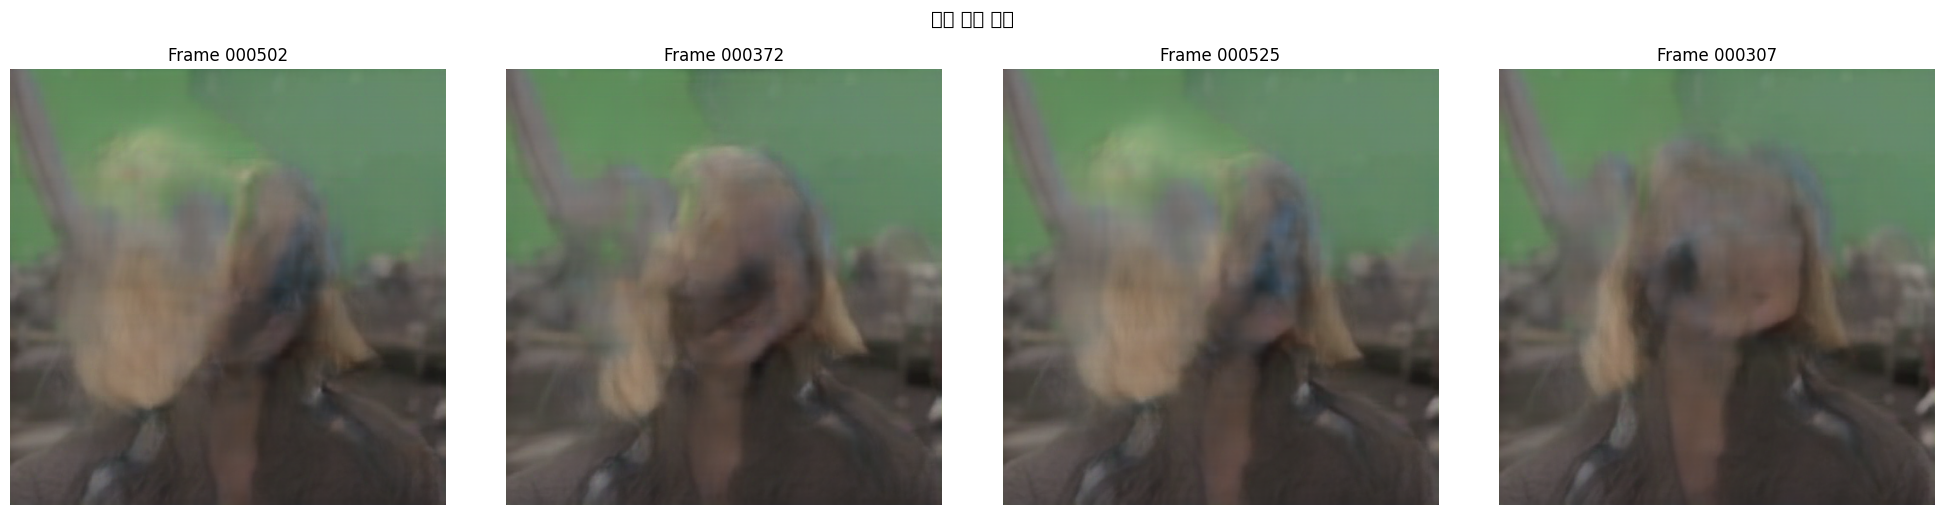


=== 파이프라인 완료 요약 ===
  원본 프레임 수  : 792
  합성 성공 프레임: 590
  최종 영상 경로  : /content/pipeline_output/output.mp4
  H.264 영상 경로 : /content/pipeline_output/output_h264.mp4


In [ ]:
import matplotlib.pyplot as plt
import random

# 합성된 프레임 샘플 미리보기
synth_samples = [
    (i, p) for i, p in enumerate(final_frame_paths)
    if i in result_dict and result_dict[i] is not None
]

if synth_samples:
    samples = random.sample(synth_samples, min(4, len(synth_samples)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, (idx, path) in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f'Frame {idx:06d}', fontsize=12)
        ax.axis('off')

    plt.suptitle('합성 결과 샘플', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  합성 결과가 없습니다. STEP 6 로그를 확인하세요.')

# 최종 요약
print('\n=== 파이프라인 완료 요약 ===')
print(f'  원본 프레임 수  : {len(frame_paths)}')
print(f'  합성 성공 프레임: {success_count}')
print(f'  최종 영상 경로  : {OUT_VIDEO_PATH}')
if os.path.exists(OUT_VIDEO_H264):
    print(f'  H.264 영상 경로 : {OUT_VIDEO_H264}')

## STEP 10 — 결과 다운로드 (Colab 전용)

In [ ]:
try:
    from google.colab import files
    target = OUT_VIDEO_H264 if os.path.exists(OUT_VIDEO_H264) else OUT_VIDEO_PATH
    if os.path.exists(target):
        files.download(target)
        print(f'✅ 다운로드 시작: {target}')
    else:
        print('⚠️  결과 영상 파일을 찾을 수 없습니다.')
except ImportError:
    print('ℹ️  Colab 환경이 아닙니다. 직접 파일을 복사하세요.')
    print(f'   경로: {OUT_VIDEO_PATH}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 시작: /content/pipeline_output/output_h264.mp4


---
## 부록: headpose.txt / landmark.txt 매핑 상세 설명

### tdmm_raw.coeffs 265차원 구조 (DECA 기준)

```
인덱스         용도                  차원
[0   : 100]   shape params          100   얼굴 형태 (PCA 계수)
[100 : 150]   texture params         50   피부 텍스처
[150 : 200]   expression params      50   표정 (눈 감기, 입 벌림 등)
[200 : 203]   global rotation         3   pitch / yaw / roll (axis-angle)
[203 : 206]   jaw rotation            3   턱 관절 회전
[206 : 209]   camera params           3   scale, tx, ty
[209 : 236]   SH lighting            27   구면 조화 조명
[236 : 265]   detail / extra         29   미세 디테일 또는 기타
```

### headpose.txt 매핑

```
headpose.txt 줄 1  ← coeffs[200]  # global pitch
headpose.txt 줄 2  ← coeffs[201]  # global yaw
headpose.txt 줄 3  ← coeffs[202]  # global roll
headpose.txt 줄 4  ← coeffs[203]  # jaw rx
headpose.txt 줄 5  ← coeffs[204]  # jaw ry
headpose.txt 줄 6  ← coeffs[205]  # jaw rz
```

### landmark.txt 매핑

```
총 72줄, 각 줄: 'x y'  (정규화 좌표, [-1, 1])

줄 0-16   얼굴 윤곽 (17점)
줄 17-21  왼쪽 눈썹 (5점)
줄 22-26  오른쪽 눈썹 (5점)
줄 27-35  코 (9점)
줄 36-47  양쪽 눈 (12점)
줄 48-67  입 (20점)
줄 68-71  추가점: 눈 중심 2, 코 1, 입 중심 1

bbox → 정규화 공식:
  cx_norm = (bbox.x + bbox.w/2) / img_w * 2 - 1
  cy_norm = (bbox.y + bbox.h/2) / img_h * 2 - 1
  sx_norm = bbox.w / img_w
  sy_norm = bbox.h / img_h
  lm_x = template_x * sx_norm + cx_norm
  lm_y = template_y * sy_norm + cy_norm
```

### 파라미터 튜닝 가이드

| 변수 | 기본값 | 효과 |
|------|--------|------|
| `MIN_FACE_AREA` | 4000 | 낮추면 더 많은 프레임 합성, 높이면 품질 우선 |
| `POSE_SLICE` | (200, 206) | headpose 계수 위치, 모델이 다르면 조정 |
| `exp_scale` | 0.02 | 표정 변형 강도 (0이면 중립 표정 유지) |